In [1]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_folder(
    folder_path="../sroie-receipt-dataset",  # change this to your actual folder path
    repo_id="SahilSheth1/sroie-receipt-dataset",  # change to your HF username
    repo_type="dataset"
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/SahilSheth1/sroie-receipt-dataset/commit/f4cfa1c9d16abdef5f5c55fd755e56def81bab7d', commit_message='Upload folder using huggingface_hub', commit_description='', oid='f4cfa1c9d16abdef5f5c55fd755e56def81bab7d', pr_url=None, pr_revision=None, pr_num=None)

In [2]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

In [3]:
BASE     = "../sroie-receipt-dataset/SROIE2019"
SPLITS   = ["train", "test"]

In [4]:
records = []
for split in SPLITS:
    img_dir = os.path.join(BASE, split, "img")
    ent_dir = os.path.join(BASE, split, "entities")

    images      = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
    entity_files = sorted([f for f in os.listdir(ent_dir)])

    print(f"\n{split.upper()}: {len(images)} images | {len(entity_files)} entity files")

    for img_file in images:
        stem = os.path.splitext(img_file)[0]
        ent_path = os.path.join(ent_dir, stem + ".txt")

        # image dimensions
        img = Image.open(os.path.join(img_dir, img_file))
        w, h = img.size

        # entity fields
        fields = {"company": None, "date": None, "address": None, "total": None}

        # Replace the entity parsing section with this:
        if os.path.exists(ent_path):
            with open(ent_path, "r", encoding="utf-8", errors="ignore") as f:
                try:
                    data = json.load(f)
                    for key in fields:
                        fields[key] = data.get(key, None) or None
                except json.JSONDecodeError:
                    pass  # leave fields as None if file is malformed

        records.append({"split": split, "file": img_file,
                         "width": w, "height": h, **fields})

df = pd.DataFrame(records)
print("\n── Dataset shape:", df.shape)
print(df.head(3))


TRAIN: 626 images | 626 entity files

TEST: 347 images | 347 entity files

── Dataset shape: (973, 8)
   split              file  width  height                          company  \
0  train  X00016469612.jpg    463    1013  BOOK TA .K (TAMAN DAYA) SDN BHD   
1  train  X00016469619.jpg    439    1004           INDAH GIFT & HOME DECO   
2  train  X00016469620.jpg    459     949        MR D.I.Y. (JOHOR) SDN BHD   

         date                                            address  total  
0  25/12/2018  NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...   9.00  
1  19/10/2018  27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...  60.30  
2    12-01-19  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  33.90  



── Image Dimensions ──
        width  height
count   973.0   973.0
mean   1359.6  2401.2
std    1444.5  1880.1
min     435.0   605.0
25%     627.0  1400.0
50%     825.0  1697.0
75%     935.0  2167.0
max    4961.0  7016.0


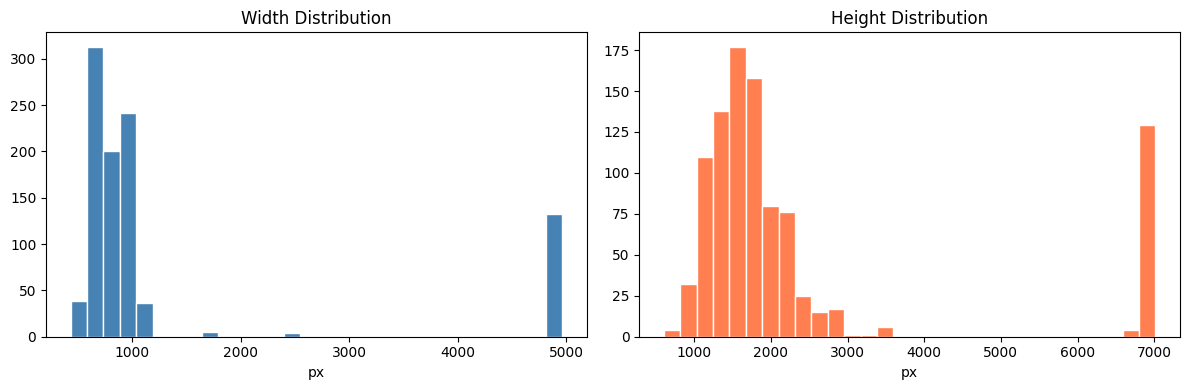

In [5]:
print("\n── Image Dimensions ──")
print(df[["width","height"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["width"],  bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Width Distribution");  axes[0].set_xlabel("px")
axes[1].hist(df["height"], bins=30, color="coral",     edgecolor="white")
axes[1].set_title("Height Distribution"); axes[1].set_xlabel("px")
plt.tight_layout()
plt.savefig("EDA_Results/eda_dimensions.png", dpi=120)
plt.show()


── Field Completeness (%) ──
company    100.0
date       100.0
address     99.9
total       99.9
dtype: float64


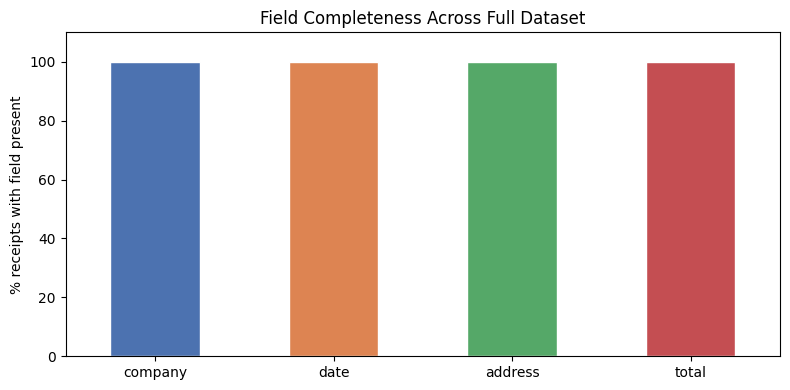

In [6]:
fields = ["company","date","address","total"]
completeness = df[fields].notnull().mean() * 100

print("\n── Field Completeness (%) ──")
print(completeness.round(1))

completeness.plot(kind="bar", color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                  edgecolor="white", figsize=(8,4))
plt.title("Field Completeness Across Full Dataset")
plt.ylabel("% receipts with field present")
plt.xticks(rotation=0); plt.ylim(0,110)
plt.tight_layout()
plt.savefig("EDA_Results/eda_completeness.png", dpi=120)
plt.show()

In [7]:
all_four = df[fields].notnull().all(axis=1).sum()
print(f"\n── Receipts with ALL 4 fields: {all_four} / {len(df)} "
      f"({100*all_four/len(df):.1f}%)")


── Receipts with ALL 4 fields: 971 / 973 (99.8%)


In [8]:
df["missing"] = df[fields].isnull().apply(
    lambda r: ", ".join([f for f in fields if pd.isnull(r[f])]) or "none", axis=1)
print("\n── Missing field patterns ──")
print(df["missing"].value_counts().head(10))


── Missing field patterns ──
missing
none    973
Name: count, dtype: int64


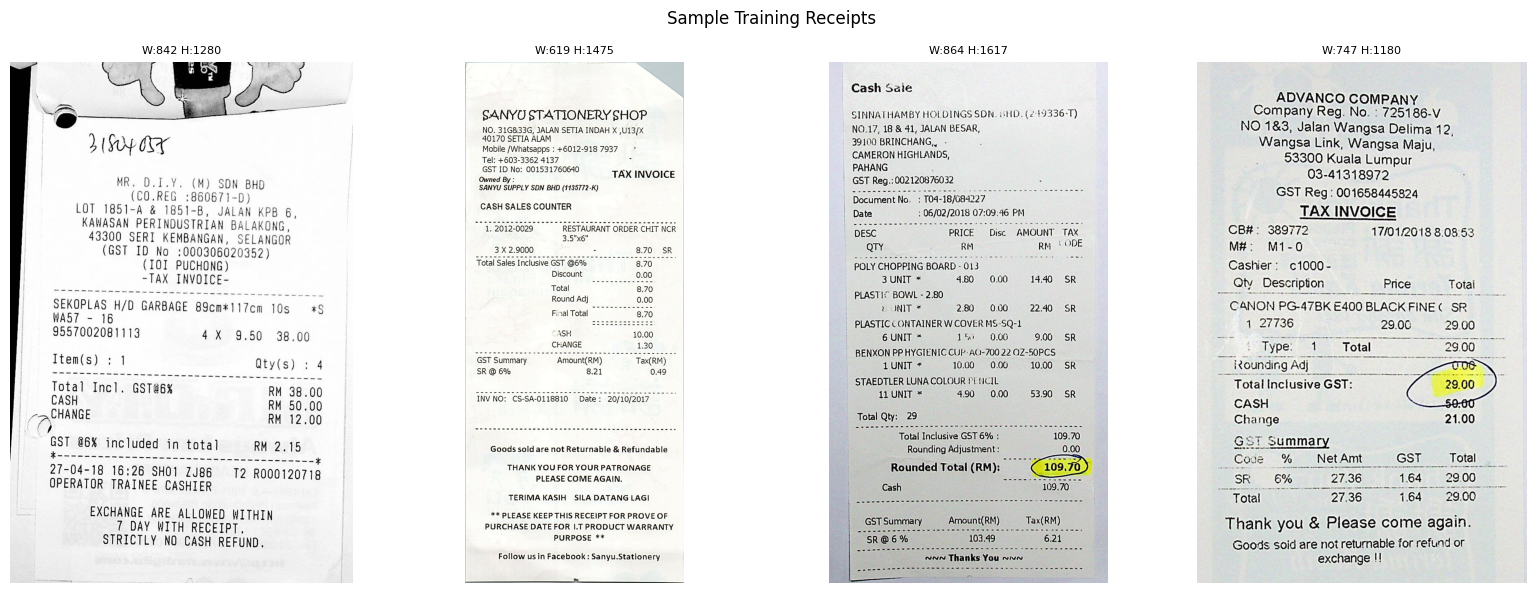


EDA complete — 3 figures saved.


In [9]:
samples = df[df["split"]=="train"].sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
for ax, (_, row) in zip(axes, samples.iterrows()):
    img = Image.open(os.path.join(BASE, row["split"], "img", row["file"]))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"W:{row['width']} H:{row['height']}", fontsize=8)
    ax.axis("off")
plt.suptitle("Sample Training Receipts")
plt.tight_layout()
plt.savefig("EDA_Results/eda_samples.png", dpi=120)
plt.show()

print("\nEDA complete — 3 figures saved.")

In [10]:
from sklearn.model_selection import train_test_split

SEED = 42

df_train_full = df[df["split"] == "train"].reset_index(drop=True)
df_test       = df[df["split"] == "test"].reset_index(drop=True)

df_train, df_val = train_test_split(df_train_full, test_size=0.1, random_state=SEED)

print(f"Train : {len(df_train)}")
print(f"Val   : {len(df_val)}")
print(f"Test  : {len(df_test)}")

Train : 563
Val   : 63
Test  : 347


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class SROIEDataset(Dataset):
    TRANSFORM = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    def __init__(self, dataframe, base_path, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform or self.TRANSFORM

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.base_path, row["split"], "img", row["file"])
        image    = Image.open(img_path).convert("RGB")
        image    = self.transform(image)

        annotation = {
            "company" : row["company"] or "",
            "date"    : row["date"]    or "",
            "address" : row["address"] or "",
            "total"   : row["total"]   or "",
        }
        return image, annotation

train_dataset = SROIEDataset(df_train, BASE)
val_dataset   = SROIEDataset(df_val,   BASE)
test_dataset  = SROIEDataset(df_test,  BASE)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 563 | Val: 63 | Test: 347


In [12]:
def collate_fn(batch):
    images      = torch.stack([item[0] for item in batch])
    annotations = [item[1] for item in batch]
    return images, annotations

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)

images, annotations = next(iter(train_loader))
print(f"Batch shape : {images.shape}")        # expect [16, 3, 224, 224]
print(f"Sample annotation: {annotations[0]}")

Batch shape : torch.Size([16, 3, 224, 224])
Sample annotation: {'company': 'GARDENIA BAKERIES (KL) SDN BHD', 'date': '19/08/2017', 'address': 'LOT 3, JALAN PELABUR 23/1, 40300 SHAH ALAM, SELANGOR.', 'total': '50.60'}


In [13]:
# Cell 12 — Tesseract + Regex Baseline (Experiment 1)
import sys
sys.path.append("../src")
from baseline import run_baseline

# Build test samples in the format baseline.py expects
test_samples = []
for _, row in df_test.iterrows():
    test_samples.append({
        "image_path": os.path.join(BASE, row["split"], "img", row["file"]),
        "annotation": {
            "company" : row["company"] or "",
            "date"    : row["date"]    or "",
            "address" : row["address"] or "",
            "total"   : row["total"]   or "",
        }
    })

# Run baseline — takes a few minutes (Tesseract processes every image)
results = run_baseline(test_samples)

# Print results
print("\n===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====")
for field, metrics in results.items():
    print(f"{field.upper():10s}  Exact Match: {metrics['exact_match']:.3f}  F1: {metrics['f1']:.3f}")

# Save for experiment log
with open("../Experiments/experiment1_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved to experiments/experiment1_results.json")

Processing 1/347: X00016469670.jpg
Processing 2/347: X00016469671.jpg
Processing 3/347: X51005200931.jpg
Processing 4/347: X51005230605.jpg
Processing 5/347: X51005230616.jpg
Processing 6/347: X51005230621.jpg
Processing 7/347: X51005230648.jpg
Processing 8/347: X51005230657.jpg
Processing 9/347: X51005230659.jpg
Processing 10/347: X51005268275.jpg
Processing 11/347: X51005268408.jpg
Processing 12/347: X51005288570.jpg
Processing 13/347: X51005301666.jpg
Processing 14/347: X51005337867.jpg
Processing 15/347: X51005337877.jpg
Processing 16/347: X51005361906.jpg
Processing 17/347: X51005361908.jpg
Processing 18/347: X51005361912.jpg
Processing 19/347: X51005361923.jpg
Processing 20/347: X51005365187.jpg
Processing 21/347: X51005433518.jpg
Processing 22/347: X51005433543.jpg
Processing 23/347: X51005433548.jpg
Processing 24/347: X51005433556.jpg
Processing 25/347: X51005442322.jpg
Processing 26/347: X51005442334.jpg
Processing 27/347: X51005442343.jpg
Processing 28/347: X51005442366.jpg
P

In [14]:
import torch
import sys
sys.path.append("../src")

from vit_model import PatchEmbedding

# Hyperparameters (match your data_loader.py which resizes to 224×224)
IMAGE_SIZE  = 224
PATCH_SIZE  = 16          # gives 14×14 = 196 patches
IN_CHANNELS = 3
EMBED_DIM   = 256         # can try 512 later; 256 is reasonable for this dataset

patch_embed = PatchEmbedding(
    image_size  = IMAGE_SIZE,
    patch_size  = PATCH_SIZE,
    in_channels = IN_CHANNELS,
    embed_dim   = EMBED_DIM,
)

print(patch_embed)
print(f"\nProjection weight shape : {patch_embed.projection_weight.shape}")
print(f"Projection bias shape   : {patch_embed.projection_bias.shape}")
print(f"Number of patches       : {patch_embed.num_patches}")

PatchEmbedding(image_size=224, patch_size=16, num_patches=196, embed_dim=256)

Projection weight shape : torch.Size([256, 768])
Projection bias shape   : torch.Size([256])
Number of patches       : 196


In [15]:
# Cell 14 — Smoke-test PatchEmbedding with a real batch
from data_loader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(BASE, batch_size=4)

images, annotations = next(iter(train_loader))   # (4, 3, 224, 224)
print(f"Input  shape : {images.shape}")

with torch.no_grad():
    embeddings = patch_embed(images)

print(f"Output shape : {embeddings.shape}")      # expect (4, 196, 256)
assert embeddings.shape == (4, patch_embed.num_patches, EMBED_DIM), "Shape mismatch!"
print("\n✓ PatchEmbedding forward pass correct")

Input  shape : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 196, 256])

✓ PatchEmbedding forward pass correct


In [16]:
# Cell 15 — Phase 3.2: Learnable Positional Embeddings
import importlib
import vit_model
importlib.reload(vit_model)
from vit_model import LearnablePositionalEmbedding, PatchAndPositionEmbedding

pos_embed = LearnablePositionalEmbedding(
    num_patches = patch_embed.num_patches,   # 196
    embed_dim   = EMBED_DIM,                 # 256
)

print(pos_embed)
print(f"\nPositional embedding tensor shape : {pos_embed.position_embeddings.shape}")
print(f"Is a trainable Parameter          : {pos_embed.position_embeddings.requires_grad}")

LearnablePositionalEmbedding(num_patches=196, embed_dim=256)

Positional embedding tensor shape : torch.Size([1, 196, 256])
Is a trainable Parameter          : True


In [17]:
# Cell 16 — Smoke-test PatchAndPositionEmbedding (full input stage)
embed_layer = PatchAndPositionEmbedding(
    image_size  = IMAGE_SIZE,
    patch_size  = PATCH_SIZE,
    in_channels = IN_CHANNELS,
    embed_dim   = EMBED_DIM,
)

print(embed_layer)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in embed_layer.parameters()):,}")

images, _ = next(iter(train_loader))   # (4, 3, 224, 224)

with torch.no_grad():
    output = embed_layer(images)

print(f"\nInput  shape : {images.shape}")
print(f"Output shape : {output.shape}")   # expect (4, 196, 256)
assert output.shape == (4, embed_layer.num_patches, EMBED_DIM), "Shape mismatch!"
print("\n✓ PatchAndPositionEmbedding forward pass correct")

PatchAndPositionEmbedding(
  (patch_embedding): PatchEmbedding(image_size=224, patch_size=16, num_patches=196, embed_dim=256)
  (positional_embedding): LearnablePositionalEmbedding(num_patches=196, embed_dim=256)
)

Total trainable parameters: 247,040

Input  shape : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 196, 256])

✓ PatchAndPositionEmbedding forward pass correct


In [18]:
# Cell 17 — Phase 3.5: Build field vocabulary from training labels
import importlib, sys
sys.path.append("../src")

import vit_model, field_vocab
importlib.reload(vit_model)
importlib.reload(field_vocab)

from data_loader  import load_sroie_split
from field_vocab  import FieldVocab

df_train, df_val, df_test = load_sroie_split(BASE)

vocab = FieldVocab.build(df_train)
vocab.save("../Experiments/vocab.json")

for field in ["vendor", "date", "total", "address"]:
    print(f"  {field:8s}  vocab size: {vocab.size(field):4d}")

✓ Vocab saved to ../Experiments/vocab.json
  vendor    vocab size:  222
  date      vocab size:  453
  total     vocab size:  441
  address   vocab size:  267


In [19]:
# Cell 18 — Phase 3.5: Instantiate ReceiptViT with field heads
from vit_model import ReceiptViT

model_exp2 = ReceiptViT(
    vocab_sizes  = vocab.vocab_sizes(),
    image_size   = IMAGE_SIZE,
    patch_size   = PATCH_SIZE,
    in_channels  = IN_CHANNELS,
    embed_dim    = EMBED_DIM,
    num_layers   = 4,
    num_heads    = 4,
    dropout      = 0.1,
)

total_params = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(model_exp2)
print(f"\nTotal trainable parameters: {total_params:,}")

with torch.no_grad():
    sample_imgs, _ = next(iter(train_loader))
    out = model_exp2(sample_imgs)

for field, logits in out.items():
    print(f"  {field:8s}  logits shape: {logits.shape}")

ReceiptViT(
  (encoder): ViTEncoder(
    num_layers=4, num_heads=4, embed_dim=256, num_patches=196
    (embedding): PatchAndPositionEmbedding(
      (patch_embedding): PatchEmbedding(image_size=224, patch_size=16, num_patches=196, embed_dim=256)
      (positional_embedding): LearnablePositionalEmbedding(num_patches=196, embed_dim=256)
    )
    (layers): Sequential(
      (0): TransformerEncoderLayer(
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): MultiHeadSelfAttention(
          num_heads=4, head_dim=64, embed_dim=256
          (qkv_proj): Linear(in_features=256, out_features=768, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (proj_dropout): Dropout(p=0.1, inplace=False)
        )
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ffn): FeedForwardBlock(
          embed_dim=256, hidden_dim=1024
          (net): 